# **Optimización TP1**: Redes Neuronales

Para esta primera parte trabajaremos con el archivo utils_tools.jl, el
dataset Iris y seguiremos los lineamientos vistos aquí. Utilizaremos una red
con tres capas (con funciones de activación ReLu, identidad y softmax) de 5
niveles.

In [1]:
using Pkg
Pkg.add(["LinearAlgebra", "RDatasets", "Random", "Statistics", "Plots"])

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed libdecor_jll ───────────────── v0.2.2+0
   Installed libfdk_aac_jll ─────────────── v2.0.4+0
   Installed x265_jll ───────────────────── v4.1.0+0
   Installed JpegTurbo_jll ──────────────── v3.1.5+0
   Installed GR_jll ─────────────────────── v0.73.24+0
   Installed LERC_jll ───────────────────── v4.1.0+0
   Installed Libmount_jll ───────────────── v2.42.0+0
   Installed LoggingExtras ──────────────── v1.2.0
   Installed Opus_jll ───────────────────── v1.6.1+0
   Installed RelocatableFolders ─────────── v1.0.1
   Installed GR ─────────────────────────── v0.73.24
   Installed Xorg_xkbcomp_jll ───────────── v1.4.7+0
   Installed Measures ───────────────────── v0.3.3
   Installed InlineStrings ──────────────── v1.4.5
   Installed ConcurrentUtilities ────────── v2.5.1
   Installed Contour ────────────────────── v0.6.3
   Installed Grisu ──────────────────────── v1.0.2
   Installed Reci

In [2]:
include("utils_tools.jl")
using LinearAlgebra, RDatasets, Random, Statistics, Plots

## **Exploración de los datos**: Dataset Iris

In [3]:
iris = dataset("datasets", "iris")
X = Matrix(iris[:, 1:4])
Y = iris.Species

150-element CategoricalArrays.CategoricalArray{String,1,UInt8}:
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 "setosa"
 ⋮
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"
 "virginica"

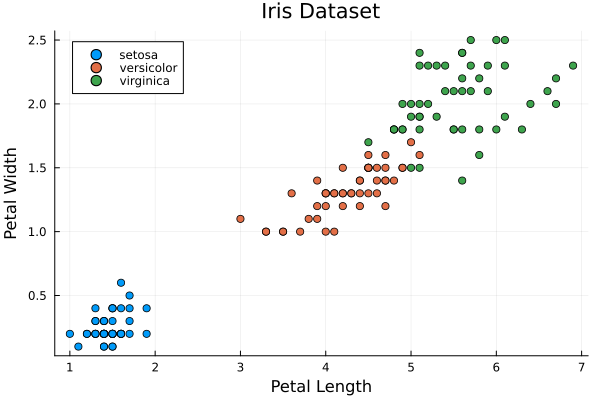

In [4]:
scatter(iris.PetalLength, 
        iris.PetalWidth, 
        group=iris.Species, 
        xlabel="Petal Length", ylabel="Petal Width",
        title="Iris Dataset", legend=:topleft)

## **Ejercicios**: Aplicación del Método de Descenso por Gradiente

In [5]:
# Conjuntos de Train y Test
X_train, Y_train, X_test, Y_test, classes = prepare_data(X, Y, do_normal=true, do_onehot=true)

([0.8463011442394174 -0.1384856417846317 … 0.6001044477334048 -0.38468233829064424; 0.3298238853402681 -1.2716331301847297 … -1.2716331301847297 -1.500412703831158; 0.7657979538652643 0.7090371419666656 … 0.7090371419666656 -0.02885341271512086; 1.0395499205151157 1.0395499205151157 … 0.9087889242239061 -0.2680600423969804], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 1.0; 1.0 1.0 … 1.0 0.0], [1.3386945372514425 1.2155961889984357 … -0.26158399003763855 1.5848912337574539; 0.3298238853402681 -0.5852944092454455 … -0.8140739828918728 -0.12773526195258872; 1.1063628252568583 0.5955155181694675 … 0.25495064677787393 1.2198844490540564; 1.4318329093887445 0.25498394276785796 … 0.12422294647664853 1.1703109168063255], [0.0 0.0 … 0.0 0.0; 0.0 1.0 … 1.0 0.0; 1.0 0.0 … 0.0 1.0], CategoricalArrays.CategoricalValue{String, UInt8}[CategoricalValue(CategoricalArrays.CategoricalPool{String, UInt8}(["setosa", "versicolor", "virginica"]), 1), CategoricalValue(CategoricalArrays.CategoricalPool{String, UInt8}(["

In [6]:
X_train

4×120 adjoint(::Matrix{Float64}) with eltype Float64:
 0.846301  -0.138486  0.107711  …  -0.877076   0.600104  -0.384682
 0.329824  -1.27163   0.329824      1.01616   -1.27163   -1.50041
 0.765798   0.709037  0.595516     -1.33435    0.709037  -0.0288534
 1.03955    1.03955   0.778028     -1.18339    0.908789  -0.26806

In [7]:
# Estrucutra de la red
mutable struct RedSimple{T<:Real}
    W1::Matrix{T}
    b1::Vector{T}
    W2::Matrix{T}
    b2::Vector{T}
    
end

In [8]:
Random.seed!(13)

W1 = randn(5, size(X_train, 1))  
b1 = randn(5)
W2 = randn(size(Y_train, 1), 5)
b2 = randn(size(Y_train, 1))

model = RedSimple(W1,b1,W2,b2)

RedSimple{Float64}([-0.2712574412158787 1.0976921309241283 0.7011938615132735 2.8879294583950395; -0.19303348432111936 1.5672559972578288 -0.6284287297996477 -0.41624174429750754; … ; -1.473266106948077 0.6325239340027606 -0.07662637741597254 -0.6962791133039559; -1.8291279823710298 0.8697672037283746 0.7144965209658968 0.32899337697016184], [0.18724925999086584, -1.4754651253784747, 0.8896488184190661, -2.2218715988721756, 0.3390483668977092], [-0.2840742360890366 -1.939036259588855 … 0.9937641194592168 -0.31215043701886147; 0.90470692845145 0.08917941810883502 … -0.04281242416010831 1.39287607027089; -0.703560132309336 -0.411368251132687 … -1.3982189469224169 -0.024092594918501072], [1.1245067489912317, 1.170921920543727, 1.9854050592572483])

### **Ejercicio 1**: Función `forward_pass`

In [9]:
# Funciones de activación
softmax(x) = exp.(x) / sum(exp.(x))
relu(x)    = max.(0, x)

relu (generic function with 1 method)

In [27]:
function forward_pass(model, x, layeroutput=false)
    # Array para backpropagation
    layerop = Vector{}()

    # Layer 1: ReLu
    z1 = model.W1 * x + model.b1
    a1 = relu(z1)               
    push!(layerop, (z1, a1))

    # Layer 2: Identidad + Softmax
    z2 = model.W2 * a1 + model.b2
    a2 = softmax(z2)
    push!(layerop, (z2, a2))

    # Condicion para retorno
    return (layeroutput ? (a2, layerop) : a2)

end

forward_pass (generic function with 2 methods)

### **Ejercicio 2**: Función `grad`

In [35]:
function grad(model, x, y)
    # Predicción del modelo
    layeroutput = true
    y_pred, layerop = forward_pass(model, x, layeroutput)
    
    # Cálculo de gradientes
    δ2  = y_pred - y
    ∇W2 = δ2 * a1'
    ∇b2 = δ2

    δ1  = (model.W2' * δ2) .* float.(z1 .> 0) 
    ∇W1 = δ1 * x'
    ∇b1 = δ1
    
    return (∇W1, ∇b1, ∇W2, ∇b2)
    
end

grad (generic function with 1 method)

### **Ejercicio 3**: Función `train!`

In [29]:
function train!(model, X, Y, η, max_iter)
    # Vector de pérdidas
    losses = Vector{Float64}()

    # Iteraciones de entrenamiento
    for k in 1:max_iter
        # Loss
        loss = mean([-sum(Y[:,j] .* log.(forward_pass(model, X[:,j]))) for j in 1:size(X,2)])
        push!(losses, loss)
        
        # Gradiente
        ∇L = grad_total(model, grad, X, Y)
        
        # Actualización de parámetros
        model.W1 = model.W1 - η * ∇L[1]
        model.b1 = model.b1 - η * ∇L[2]
        model.W2 = model.W2 - η * ∇L[3]
        model.b2 = model.b2 - η * ∇L[4]

        # Criterio de parada
        if sum(norm.(∇L)) < 1e-6
            break
            
        end
    end
    return model, losses
    
end

train! (generic function with 1 method)

### **Ejercicio 4**: Función `results`

In [30]:
function results(model, X_train, Y_train, X_test, Y_test, losses)    
    # Gráfico de pérdida
    grafico = plot(losses, xlabel="Iteración", ylabel="Loss", title="Convergencia", legend=false)
    
    # Accuracy en train
    train_predicted = 0
    for j in 1:size(X_train, 2)
        y_pred = argmax(forward_pass(model, X_train[:,j]))
        y_real = argmax(Y_train[:,j])
        train_predicted += (y_pred == y_real)
        
    end
    acc_train = train_predicted / size(X_train, 2)
    
    # Accuracy en test
    test_predicted = 0
    for j in 1:size(X_test, 2)
        y_pred = argmax(forward_pass(model, X_test[:,j]))
        y_real = argmax(Y_test[:,j])
        test_predicted += (y_pred == y_real)
        
    end
    acc_test = test_predicted / size(X_test, 2)
    return grafico, acc_train, acc_test
    
end

results (generic function with 1 method)

## **Resultados**

### **Entrenamiento**: Medición del tiempo de entrenamiento

In [17]:
# Definimos parámetros de entrenamiento
η = 0.05
max_iter = 1000

1000

In [37]:
@time model, losses = train!(model, X_train, Y_train, η, max_iter)

LoadError: UndefVarError: `a1` not defined

### **Loss & Accuracy**: Gráfico & valores en train y test

In [19]:
grafico, acc_train, acc_test = results(model, X_train, Y_train, X_test, Y_test, losses) 

(Plot{Plots.GRBackend() n=1}, 0.9666666666666667, 0.9666666666666667)

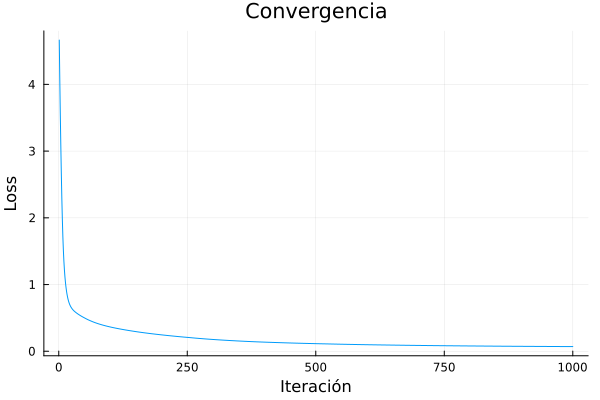

In [20]:
grafico

In [21]:
losses

1000-element Vector{Float64}:
 4.664481825985349
 4.08444901584012
 3.5581335307527002
 3.0870837420672195
 2.6625878409522983
 2.2884394618944386
 1.97398262994161
 1.7152853014266822
 1.5101171754673006
 1.3483806191362786
 1.2202739444993567
 1.1173123369672149
 1.033722667991675
 ⋮
 0.07027365101745976
 0.07023625422532195
 0.0701989354243137
 0.0701616943234076
 0.07012453063354095
 0.07008744406758823
 0.07004992731320364
 0.07000906520764372
 0.06996830061918548
 0.06992763260047755
 0.06988706028223306
 0.06984658286361561

In [22]:
# Accuracy en train
print("Accuracy en train: ", acc_train)

Accuracy en train: 0.9666666666666667

In [23]:
# Accuracy en test
print("Accuracy en test: ", acc_test)

Accuracy en test: 0.9666666666666667